In [ ]:
pip install lightgbm mlflow --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [ ]:
nifty   = pd.read_csv('nifty50.csv', parse_dates=['date'])
bnifty  = pd.read_csv('banknifty.csv', parse_dates=['date'])
vix     = pd.read_csv('indiavix.csv', parse_dates=['date'])
starter = pd.read_csv('starter_features.csv', parse_dates=['date'])

for df in [nifty, bnifty, vix, starter]:
  df.sort_values('date', inplace=True)
  df.reset_index(drop=True, inplace=True)

print('nifty   :', nifty.shape,   '|', nifty['date'].min().date(),   '->', nifty['date'].max().date())
print('bnifty  :', bnifty.shape,  '|', bnifty['date'].min().date(),  '->', bnifty['date'].max().date())
print('vix     :', vix.shape,     '|', vix['date'].min().date(),     '->', vix['date'].max().date())
print('starter :', starter.shape, '|', starter['date'].min().date(), '->', starter['date'].max().date())

nifty   : (988, 7) | 2022-01-03 -> 2025-12-31
bnifty  : (987, 7) | 2022-01-03 -> 2025-12-31
vix     : (983, 7) | 2022-01-03 -> 2025-12-31
starter : (988, 32) | 2022-01-03 -> 2025-12-31


In [ ]:
print('1. ROW COUNTS')
print(f'  nifty   : {len(nifty)} rows')
print(f'  bnifty  : {len(bnifty)} rows')
print(f'  vix     : {len(vix)} rows')
print(f'  starter : {len(starter)} rows')

print("-")

print('2. COLUMN NAMES')
print('nifty   :', list(nifty.columns))
print('starter :', list(starter.columns))
nifty_dates   = set(nifty['date'])
starter_dates = set(starter['date'])
extra_in_starter = starter_dates - nifty_dates
missing_in_starter = nifty_dates - starter_dates

print("-")

print(f'Dates in starter but not nifty  : {len(extra_in_starter)}')
print(f'Dates in nifty but not starter  : {len(missing_in_starter)}')

if extra_in_starter:
  print('Extra dates:', sorted(extra_in_starter)[:5])
if missing_in_starter:
  print('Missing dates:', sorted(missing_in_starter)[:5])


1. ROW COUNTS
  nifty   : 988 rows
  bnifty  : 987 rows
  vix     : 983 rows
  starter : 988 rows
-
2. COLUMN NAMES
nifty   : ['date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
starter : ['date', 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_intraday', 'ret_overnight', 'high_low_range', 'log_volume', 'volume_ratio_20d', 'close_vs_ma5', 'close_vs_ma20', 'close_vs_ma50', 'momentum_5_20', 'vol_5d', 'vol_20d', 'vol_50d', 'rsi_14', 'bn_ret_1d', 'bn_ret_5d', 'nifty_bn_spread', 'nifty_bn_corr_20d', 'vix_level', 'vix_change', 'vix_5d_change', 'vix_ma_ratio', 'close_vs_252d_high', 'close_vs_252d_low', 'dow', 'ret_zscore', 'ma5_smooth_signal', 'volume_normalized']
-
Dates in starter but not nifty  : 0
Dates in nifty but not starter  : 0


In [ ]:
print('NULL COUNT IN STARTER FEATURES')
nulls = starter.isnull().sum()
print(nulls.to_string())
print('-')
print('SUSPICIOUS NULL COUNTS')
suspicious = nulls[nulls > 50]
for col, cnt in suspicious.items():
  print(f'  {col}: {cnt} NaNs  <-- investigate')

NULL COUNT IN STARTER FEATURES
date                    0
ret_1d                  1
ret_5d                  5
ret_10d                10
ret_20d                20
ret_intraday            0
ret_overnight           1
high_low_range          0
log_volume              8
volume_ratio_20d      141
close_vs_ma5            4
close_vs_ma20          19
close_vs_ma50          49
momentum_5_20          20
vol_5d                  5
vol_20d                20
vol_50d                50
rsi_14                 14
bn_ret_1d               1
bn_ret_5d               5
nifty_bn_spread         1
nifty_bn_corr_20d      20
vix_level               0
vix_change              1
vix_5d_change           5
vix_ma_ratio           19
close_vs_252d_high    251
close_vs_252d_low     251
dow                     0
ret_zscore              1
ma5_smooth_signal       4
volume_normalized       8
-
SUSPICIOUS NULL COUNTS
  volume_ratio_20d: 141 NaNs  <-- investigate
  close_vs_252d_high: 251 NaNs  <-- investigate
  close_vs_252d_lo

In [ ]:
merged = starter.merge(nifty[['date', 'Close']], on='date', how='left')
merged = merged.sort_values('date').reset_index(drop=True)

merged['our_ret_1d'] = merged['Close'].pct_change()
diff = (merged['ret_1d'] - merged['our_ret_1d']).abs()
print('Max difference between starter ret_1d and our computed ret_1d:')
print(f'  {diff.max():.2e}')
if diff.max() < 1e-10:
  print('PASS: ret_1d is backward-looking (safe to use)')
else:
  print('FAIL: ret_1d does NOT match backward return (possible leakage)')

Max difference between starter ret_1d and our computed ret_1d:
  9.97e-17
PASS: ret_1d is backward-looking (safe to use)


In [ ]:
merged2 = starter.merge(nifty[['date', 'Open', 'Close']], on='date', how='left')

merged2 = merged2.sort_values('date').reset_index(drop=True)
merged2['our_overnight'] = (merged2['Open'] - merged2['Close'].shift(1)) / merged2['Close'].shift(1)


diff2 = (merged2['ret_overnight'] - merged2['our_overnight']).abs()
print('Max difference ret_overnight vs our computed overnight:')
print(f'  {diff2.max():.2e}')

if diff2.max() < 1e-10:
  print('PASS: ret_overnight is safe')

else:
  print('FAIL: ret_overnight looks leaky')

Max difference ret_overnight vs our computed overnight:
  9.95e-17
PASS: ret_overnight is safe


In [ ]:
s = starter[['date', 'close_vs_ma5', 'ma5_smooth_signal']].dropna().copy()
s['trailing_ma5'] = s['close_vs_ma5'].rolling(5).mean()
s['centered_ma5'] = s['close_vs_ma5'].rolling(5, center=True).mean()

diff_trailing = (s['ma5_smooth_signal'] - s['trailing_ma5']).abs().mean()
diff_centered = (s['ma5_smooth_signal'] - s['centered_ma5']).abs().mean()

print('Mean absolute diff vs trailing MA5 :', round(diff_trailing, 6))
print('Mean absolute diff vs centered MA5 :', round(diff_centered, 6))

print(' Neither matches well ')

print('Construction of ma5_smooth_signal is unverifiable.')
print('DECISION: DROP this column. Mention in data audit section of report.')
print('Sample comparison:')

print(s[['date','close_vs_ma5','ma5_smooth_signal','trailing_ma5','centered_ma5']].head(10).to_string(index = False))

Mean absolute diff vs trailing MA5 : 0.005789
Mean absolute diff vs centered MA5 : 0.00612
 Neither matches well 
Construction of ma5_smooth_signal is unverifiable.
DECISION: DROP this column. Mention in data audit section of report.
Sample comparison:
      date  close_vs_ma5  ma5_smooth_signal  trailing_ma5  centered_ma5
2022-01-07      0.001672          -0.005354           NaN           NaN
2022-01-10      0.008109           0.002076           NaN           NaN
2022-01-11      0.008218          -0.000699           NaN      0.008439
2022-01-12      0.013712           0.003049           NaN      0.009192
2022-01-13      0.010484           0.002187      0.008439      0.008560
2022-01-14      0.005439           0.001445      0.009192      0.005640
2022-01-17      0.004948           0.007344      0.008560      0.000298
2022-01-18     -0.006383           0.002135      0.005640     -0.005311
2022-01-19     -0.012997          -0.000465      0.000298     -0.010072
2022-01-20     -0.017564   

In [ ]:

nifty_sorted = nifty.sort_values('date').reset_index(drop=True).copy()

nifty_sorted['next_ret'] = nifty_sorted['Close'].pct_change().shift(-1)
nifty_sorted['target'] = (nifty_sorted['next_ret'] > 0).astype(int)
print('CLASS DISTRIBUTION (for all rows)')
print(nifty_sorted['target'].value_counts())

print(f'Up fraction: {nifty_sorted["target"].mean():.3f}')

near_zero = nifty_sorted['next_ret'].abs() < 0.001
print(f'Near-zero return rows (< 0.1%): {near_zero.sum()}')
print(f'These will be dropped from training only')
print('CLASS DISTRIBUTION (after dropping near zeroes)')
clean = nifty_sorted[~near_zero]
print(clean['target'].value_counts())

print(f'Up fraction: {clean["target"].mean():.3f}')


CLASS DISTRIBUTION (for all rows)
target
1    524
0    464
Name: count, dtype: int64
Up fraction: 0.530
Near-zero return rows (< 0.1%): 115
These will be dropped from training only
CLASS DISTRIBUTION (after dropping near zeroes)
target
1    465
0    408
Name: count, dtype: int64
Up fraction: 0.533


In [ ]:
nifty_clean = nifty_sorted[['date', 'Open', 'High', 'Low', 'Close', 'Volume' ,'next_ret', 'target']].copy()
features = ['ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'rsi_14', 'vix_level', 'vix_change', 'close_vs_ma20', 'close_vs_ma50', 'bn_ret_1d', 'high_low_range', 'dow']
starter_subset = starter[['date'] + features].copy()

master = nifty_clean.merge(starter_subset, on='date', how='left')
master = master.sort_values('date').reset_index(drop=True)
print('Master dataframe shape:', master.shape)
print('Columns:', list(master.columns))
print(master.head(3).to_string())

Master dataframe shape: (988, 20)
Columns: ['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'next_ret', 'target', 'ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'rsi_14', 'vix_level', 'vix_change', 'close_vs_ma20', 'close_vs_ma50', 'bn_ret_1d', 'high_low_range', 'dow']
        date          Open          High           Low         Close  Volume  next_ret  target    ret_1d  ret_5d  ret_20d  vol_20d  rsi_14  vix_level  vix_change  close_vs_ma20  close_vs_ma50  bn_ret_1d  high_low_range  dow
0 2022-01-03  17387.150391  17646.650391  17383.300781  17625.699219  200500  0.010187       1       NaN     NaN      NaN      NaN     NaN  16.450001         NaN            NaN            NaN        NaN        0.014941    0
1 2022-01-04  17681.400391  17827.599609  17593.550781  17805.250000  247400  0.006740       1  0.010187     NaN      NaN      NaN     NaN  16.120001   -0.020061            NaN            NaN   0.011483        0.013145    1
2 2022-01-05  17820.099609  17944.699219  17748.849609  17925

In [ ]:
IS_END = '2025-06-30'
OOS_START = '2025-07-01'

df_train = master[master['date'] <= IS_END].copy()
df_oos = master[master['date'] >= OOS_START].copy()

df_train = df_train[df_train['next_ret'].abs() >= 0.001].copy()
df_train = df_train.dropna(subset=features).reset_index(drop=True)
df_oos = df_oos.dropna(subset=features).reset_index(drop=True)

print('In-sample rows :', len(df_train))
print('OOS rows :', len(df_oos))
print('IS date range :', df_train['date'].min().date(), '->', df_train['date'].max().date())
print('OOS date range :', df_oos['date'].min().date(), '->', df_oos['date'].max().date())
print('IS class balance:')
print(df_train['target'].value_counts())
print('locking OOS data xurrently.')

In-sample rows : 717
OOS rows : 126
IS date range : 2022-03-15 -> 2025-06-27
OOS date range : 2025-07-01 -> 2025-12-31
IS class balance:
target
1    389
0    328
Name: count, dtype: int64
locking OOS data xurrently.


In [ ]:
master.to_csv('master_data.csv', index=False)
df_train.to_csv('df_train.csv', index=False)
df_oos.to_csv('df_oos.csv', index=False)

Figure

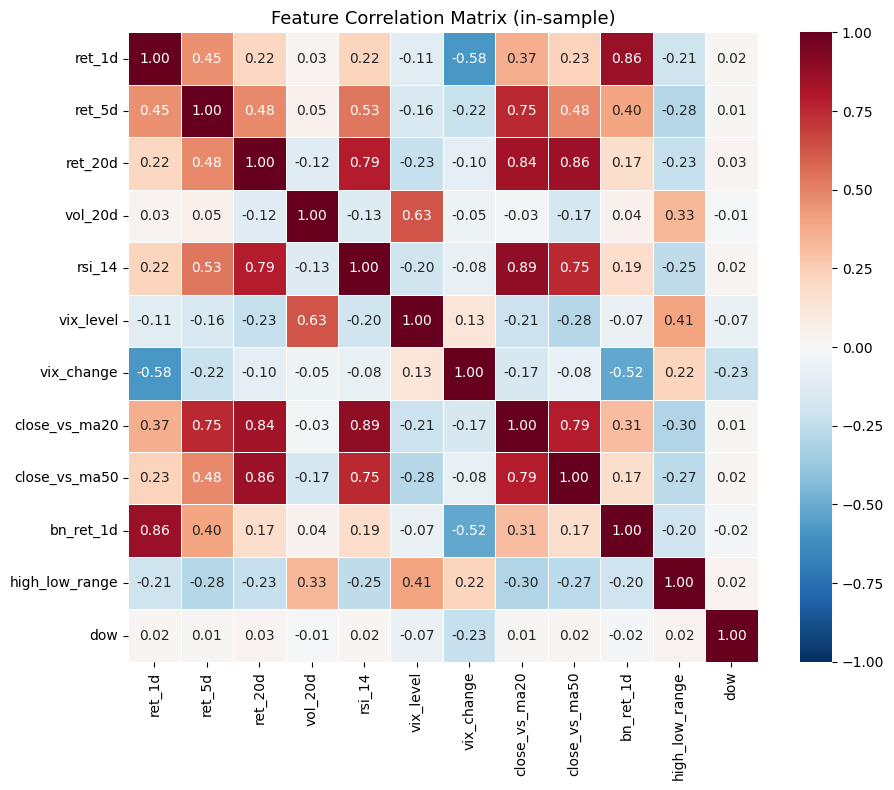

HIGH CORRELATED PAIRS (|r| > 0.75)
  ret_1d               vs bn_ret_1d             r = 0.863  <-- consider dropping one
  ret_5d               vs close_vs_ma20         r = 0.752  <-- consider dropping one
  ret_20d              vs rsi_14                r = 0.785  <-- consider dropping one
  ret_20d              vs close_vs_ma20         r = 0.838  <-- consider dropping one
  ret_20d              vs close_vs_ma50         r = 0.858  <-- consider dropping one
  rsi_14               vs close_vs_ma20         r = 0.888  <-- consider dropping one
  rsi_14               vs close_vs_ma50         r = 0.751  <-- consider dropping one
  close_vs_ma20        vs close_vs_ma50         r = 0.787  <-- consider dropping one
No pairs above 0.75 : all 12 features are sufficiently independent


In [ ]:
import seaborn as sns
features = ['ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'rsi_14', 'vix_level', 'vix_change', 'close_vs_ma20', 'close_vs_ma50', 'bn_ret_1d', 'high_low_range', 'dow']
corr = df_train[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix (in-sample)', fontsize=13)

plt.tight_layout()
plt.savefig('plot1_correlation.png', dpi=150)
plt.show()
print('HIGH CORRELATED PAIRS (|r| > 0.75)')

found = False
for i in range(len(features)):
  for j in range(i+1, len(features)):
    r = corr.iloc[i, j]
    if abs(r) > 0.75:
      print(f'  {features[i]:20s} vs {features[j]:20s}  r = {r:.3f}  <-- consider dropping one')
      ound = True
if not found:
  print('No pairs above 0.75 : all 12 features are sufficiently independent')

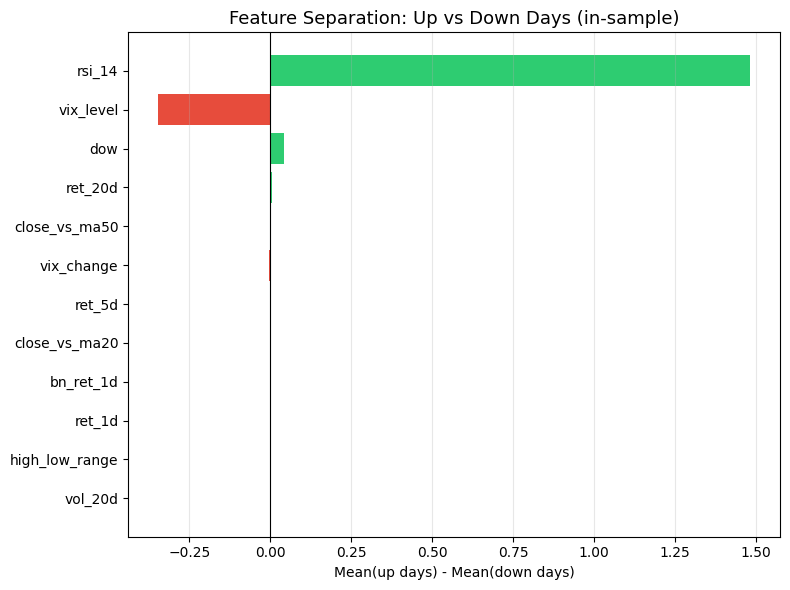

FEATURE TABLE
Feature             Mean(up)  Mean(down)      Diff
-------------------------------------------------------
vol_20d                  0.0081     0.0083    -0.0002


In [ ]:
means = df_train.groupby('target')[features].mean()
diff  = (means.loc[1] - means.loc[0])
diff_sorted = diff.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if diff[f] < 0 else '#2ecc71' for f in diff_sorted.index]

ax.barh(diff_sorted.index, diff[diff_sorted.index], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean(up days) - Mean(down days)')
ax.set_title('Feature Separation: Up vs Down Days (in-sample)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot2_feature_separation.png', dpi=150)
plt.show()

print('FEATURE TABLE')
print(f'{"Feature":20}{"Mean(up)":10}{"Mean(down)":10}{"Diff":>10}')


print('-' * 55)
for f in diff.abs().sort_values(ascending=False).index:
  mu = means.loc[1, f]
  md = means.loc[0, f]
print(f'{f:20s} {mu:>10.4f} {md:>10.4f} {mu-md:>10.4f}')

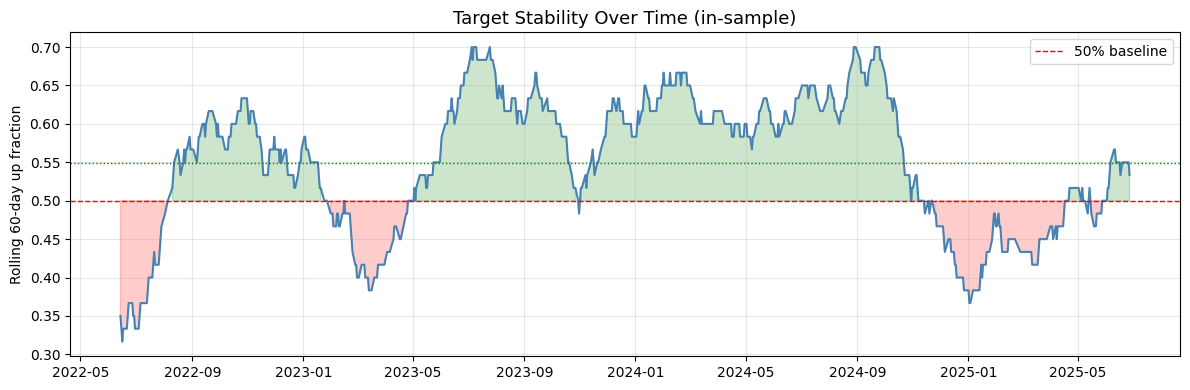

Interpretation:
  Periods above 0.5 = bull regime (more up days than down)
  Periods below 0.5 = bear regime
  Large swings = regime changes — walk-forward handles this naturally


In [ ]:
ts = df_train.set_index('date')['target'].copy()
rolling_up = ts.rolling(60).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_up.index, rolling_up.values, color='steelblue', linewidth=1.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.axhline(rolling_up.mean(), color='green', linestyle=':', linewidth=1)

label=f'Overall mean = {rolling_up.mean():.3f}'

ax.fill_between(rolling_up.index, 0.5, rolling_up.values, where=rolling_up.values > 0.5, alpha=0.2, color='green')
ax.fill_between(rolling_up.index, 0.5, rolling_up.values, where=rolling_up.values < 0.5, alpha=0.2, color='red')

ax.set_ylabel('Rolling 60-day up fraction')
ax.set_title('Target Stability Over Time (in-sample)', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_target_stability.png', dpi=150)
plt.show()

print('Interpretation:')
print('  Periods above 0.5 = bull regime (more up days than down)')
print('  Periods below 0.5 = bear regime')
print('  Large swings = regime changes — walk-forward handles this naturally')

In [ ]:
justifications = {
    'ret_1d':         'Prior day return; captures short-term momentum/mean-reversion',
    'ret_5d':         'Weekly return; medium-term momentum signal',
    'ret_20d':        'Monthly return; medium-term trend direction',
    'vol_20d':        'Realized volatility; identifies low/high volatility regimes',
    'rsi_14':         'RSI(14); overbought/oversold mean-reversion signal',
    'vix_level':      'India VIX level; absolute fear/uncertainty in the market',
    'vix_change':     'VIX 1-day change; spike in fear predicts down moves',
    'close_vs_ma20':  'Price relative to 20-day MA; short-term trend filter',
    'close_vs_ma50':  'Price relative to 50-day MA; medium-term trend filter',
    'bn_ret_1d':      'Bank Nifty prior return; leading cross-asset signal for NIFTY',
    'high_low_range': 'Intraday H-L range; proxy for intraday uncertainty/volatility',
    'dow':            'Day of week; captures known calendar effects in Indian markets',
}

safe_timestamps = {
    'ret_1d':         'Close of day T',
    'ret_5d':         'Close of day T',
    'ret_20d':        'Close of day T',
    'vol_20d':        'Close of day T',
    'rsi_14':         'Close of day T',
    'vix_level':      'Close of day T (VIX published EOD)',
    'vix_change':     'Close of day T',
    'close_vs_ma20':  'Close of day T',
    'close_vs_ma50':  'Close of day T',
    'bn_ret_1d':      'Close of day T (BN closes same time as NIFTY)',
    'high_low_range': 'Close of day T',
    'dow':            'Known at start of day T',
}

features = list(justifications.keys())

print(f'{"#":>2}  {"Feature":20s}  {"Safe at":25s}  Justification')
print('-' * 100)

for i, f in enumerate(features, 1):
    print(f'{i:>2}. {f:20s}  {safe_timestamps[f]:25s}  {justifications[f]}')

print('--')

print("Dropped features and reasons:")
dropped_reasons = [
    ('ma5_smooth_signal',  'construction unverifiable, cannot confirm no lookahead'),
    ('close_vs_252d_high', '251 NaN warmup rows, wastes 1yr of training data'),
    ('close_vs_252d_low',  'same reason'),
    ('volume_normalized',  'redundant with log_volume, not in final 12'),
    ('volume_ratio_20d',   '141 unexplained NaNs, construction unclear'),
    ('ret_10d',            'collinear with ret_5d and ret_20d, redundant'),
    ('ret_intraday',       'same-day open-to-close, safely known but low signal'),
    ('ret_overnight',      'safely known but captures gap, low marginal value'),
    ('vol_5d, vol_50d',    'covered by vol_20d; avoid multicollinearity'),
    ('momentum_5_20',      'derived from ret_5d & ret_20d already in features'),
    ('bn_ret_5d',          'collinear with bn_ret_1d'),
    ('nifty_bn_spread',    'collinear with bn_ret_1d'),
    ('nifty_bn_corr_20d',  'rolling correlation, marginal value'),
    ('vix_5d_change',      'covered by vix_change'),
    ('vix_ma_ratio',       'derived from vix_level already in features'),
    ('ret_zscore',         'standardized ret_1d — redundant'),
    ('log_volume',         'volume signal, dropped in favour of high_low_range'),
    ('close_vs_ma5',       'shorter MA, noisier than close_vs_ma20')
]

for feat, reason in dropped_reasons:
    print(f'  {feat:20s}: {reason}')

 #  Feature               Safe at                    Justification
----------------------------------------------------------------------------------------------------
 1. ret_1d                Close of day T             Prior day return; captures short-term momentum/mean-reversion
 2. ret_5d                Close of day T             Weekly return; medium-term momentum signal
 3. ret_20d               Close of day T             Monthly return; medium-term trend direction
 4. vol_20d               Close of day T             Realized volatility; identifies low/high volatility regimes
 5. rsi_14                Close of day T             RSI(14); overbought/oversold mean-reversion signal
 6. vix_level             Close of day T (VIX published EOD)  India VIX level; absolute fear/uncertainty in the market
 7. vix_change            Close of day T             VIX 1-day change; spike in fear predicts down moves
 8. close_vs_ma20         Close of day T             Price relative to 20-day MA; s

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

y_true = df_train['target'].values

majority_class = int(df_train['target'].mode()[0])
y_majority = np.full(len(y_true), majority_class)
acc_majority = accuracy_score(y_true, y_majority)
bal_majority = balanced_accuracy_score(y_true, y_majority)

np.random.seed(42)
y_random = np.random.randint(0, 2, len(y_true))
acc_random = accuracy_score(y_true, y_random)
bal_random = balanced_accuracy_score(y_true, y_random)

y_persist = (df_train['ret_1d'] > 0).astype(int).values
acc_persist = accuracy_score(y_true, y_persist)
bal_persist = balanced_accuracy_score(y_true, y_persist)

print('BASELINES')
print(f'{"Baseline":20s} {"Accuracy":>10s} {"Balanced Acc":>14s}')

print('-' * 48)
print(f'{"Majority class":20s} {acc_majority:>10.3f} {bal_majority:>14.3f}')
print(f'{"Random":20s} {acc_random:>10.3f} {bal_random:>14.3f}')
print(f'{"Persistence":20s} {acc_persist:>10.3f} {bal_persist:>14.3f}')

BASELINES
Baseline               Accuracy   Balanced Acc
------------------------------------------------
Majority class            0.543          0.500
Random                    0.509          0.507
Persistence               0.551          0.548


In [ ]:
from google.colab import files
files.download('plot1_correlation.png')
files.download('plot2_feature_separation.png')
files.download('plot3_target_stability.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TRAINING

In [ ]:
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
mlflow.set_experiment('nifty_direction_wf')

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Experiment: nifty_direction_wf')
print('MLflow ready.')

2026/05/12 09:38:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/12 09:38:32 INFO mlflow.store.db.utils: Updating database tables
2026/05/12 09:38:35 INFO mlflow.tracking.fluent: Experiment with name 'nifty_direction_wf' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////content/mlflow.db
Experiment: nifty_direction_wf
MLflow ready.


In [ ]:
features = ['ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'rsi_14', 'vix_level', 'vix_change', 'close_vs_ma20', 'close_vs_ma50', 'bn_ret_1d', 'high_low_range', 'dow']

TRAIN_DAYS = 252
TEST_DAYS  = 21
STEP_DAYS  = 21

n = len(df_train)
folds = []
start = 0

while start + TRAIN_DAYS + TEST_DAYS <= n:
    train_end  = start + TRAIN_DAYS
    test_end   = train_end + TEST_DAYS
    folds.append((start, train_end, train_end, test_end))
    start += STEP_DAYS

print(f'Total folds: {len(folds)}')
print(f'Train window: {TRAIN_DAYS} days  |  Test window: {TEST_DAYS} days  |  Step: {STEP_DAYS} days')

f0 = folds[0]
fl = folds[-1]

print('First fold:')
print(f'  Train: {df_train["date"].iloc[f0[0]].date()} -> {df_train["date"].iloc[f0[1]-1].date()}')
print(f'  Test : {df_train["date"].iloc[f0[2]].date()} -> {df_train["date"].iloc[f0[3]-1].date()}')
print('Last fold:')
print(f'  Train: {df_train["date"].iloc[fl[0]].date()} -> {df_train["date"].iloc[fl[1]-1].date()}')
print(f'  Test : {df_train["date"].iloc[fl[2]].date()} -> {df_train["date"].iloc[fl[3]-1].date()}')

Total folds: 22
Train window: 252 days  |  Test window: 21 days  |  Step: 21 days
First fold:
  Train: 2022-03-15 -> 2023-04-26
  Test : 2023-04-27 -> 2023-05-31
Last fold:
  Train: 2024-03-05 -> 2025-05-22
  Test : 2025-05-23 -> 2025-06-24


In [ ]:
LGB_PARAMS = dict(
    n_estimators      = 200,
    max_depth          = 4,
    learning_rate     = 0.05,
    num_leaves        = 15,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_lambda        = 1.0,
    class_weight      = 'balanced',
    random_state      = 42,
    verbose            = -1,
)

print('LightGBM hyperparameters:')
for k, v in LGB_PARAMS.items():
    print(f'  {k:25s}: {v}')

LightGBM hyperparameters:
  n_estimators             : 200
  max_depth                : 4
  learning_rate            : 0.05
  num_leaves               : 15
  min_child_samples        : 20
  subsample                : 0.8
  colsample_bytree         : 0.8
  reg_lambda               : 1.0
  class_weight             : balanced
  random_state             : 42
  verbose                  : -1


In [ ]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

fold_results = []
all_preds    = []

with mlflow.start_run(run_name='walk_forward_main'):
    mlflow.log_params(LGB_PARAMS)
    mlflow.log_param('train_days', TRAIN_DAYS)
    mlflow.log_param('test_days',  TEST_DAYS)
    mlflow.log_param('n_folds',    len(folds))
    mlflow.log_param('features',   ','.join(features))

    for fold_idx, (tr_start, tr_end, te_start, te_end) in enumerate(folds):
        train_fold = df_train.iloc[tr_start:tr_end]
        test_fold  = df_train.iloc[te_start:te_end]

        X_train = train_fold[features].values
        y_train = train_fold['target'].values  # Change 'features' to 'target'
        y_test  = test_fold['target'].values
        X_test  = test_fold[features].values

        if len(np.unique(y_test)) < 2:
            continue
        model = lgb.LGBMClassifier(**LGB_PARAMS)
        model.fit(X_train, y_train)
        prob  = model.predict_proba(X_test)[:, 1]
        pred  = (prob >= 0.5).astype(int)
        auc      = roc_auc_score(y_test, prob)
        bal_acc  = balanced_accuracy_score(y_test, pred)

        fold_results.append({
            'fold'     : fold_idx,
            'test_start': test_fold['date'].iloc[0],
            'test_end'  : test_fold['date'].iloc[-1],
            'auc'      : auc,
            'bal_acc'  : bal_acc,
            'n_train'  : len(train_fold),
            'n_test'   : len(test_fold),
        })

        for i, idx in enumerate(test_fold.index):
            all_preds.append({
                'date'  : test_fold['date'].iloc[i],
                'y_true': y_test[i],
                'prob'  : prob[i],
                'pred'  : pred[i],
            })

        mlflow.log_metric('fold_auc',     auc,      step=fold_idx)
        mlflow.log_metric('fold_bal_acc', bal_acc, step=fold_idx)

        print(f'Fold {fold_idx+1:2d} | '
              f'{test_fold["date"].iloc[0].date()} -> {test_fold["date"].iloc[-1].date()} | '
              f'AUC={auc:.3f}  BalAcc={bal_acc:.3f}')

    aucs     = [r['auc']     for r in fold_results]
    bal_accs = [r['bal_acc'] for r in fold_results]

    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)
    mean_bal = np.mean(bal_accs)
    std_bal  = np.std(bal_accs)

    mlflow.log_metric('mean_auc',      mean_auc)
    mlflow.log_metric('std_auc',       std_auc)
    mlflow.log_metric('mean_bal_acc', mean_bal)
    mlflow.log_metric('std_bal_acc',  std_bal)

    print('IN SAMPLE')
    print(f'Mean AUC          : {mean_auc:.3f}  ±  {std_auc:.3f}')
    print(f'Mean Balanced Acc : {mean_bal:.3f}  ±  {std_bal:.3f}')
    print(f'Folds completed   : {len(fold_results)}')

Fold  1 | 2023-04-27 -> 2023-05-31 | AUC=0.423  BalAcc=0.418
Fold  2 | 2023-06-01 -> 2023-07-03 | AUC=0.511  BalAcc=0.533
Fold  3 | 2023-07-05 -> 2023-08-04 | AUC=0.529  BalAcc=0.558
Fold  4 | 2023-08-07 -> 2023-09-08 | AUC=0.673  BalAcc=0.673
Fold  5 | 2023-09-12 -> 2023-10-18 | AUC=0.418  BalAcc=0.445
Fold  6 | 2023-10-19 -> 2023-11-24 | AUC=0.546  BalAcc=0.597
Fold  7 | 2023-11-28 -> 2023-12-28 | AUC=0.788  BalAcc=0.588
Fold  8 | 2024-01-01 -> 2024-01-31 | AUC=0.382  BalAcc=0.373
Fold  9 | 2024-02-01 -> 2024-03-04 | AUC=0.469  BalAcc=0.429
Fold 10 | 2024-03-05 -> 2024-04-16 | AUC=0.645  BalAcc=0.668
Fold 11 | 2024-04-18 -> 2024-05-22 | AUC=0.422  BalAcc=0.400
Fold 12 | 2024-05-24 -> 2024-06-25 | AUC=0.529  BalAcc=0.433
Fold 13 | 2024-06-26 -> 2024-08-07 | AUC=0.361  BalAcc=0.417
Fold 14 | 2024-08-08 -> 2024-09-16 | AUC=0.325  BalAcc=0.419
Fold 15 | 2024-09-17 -> 2024-10-21 | AUC=0.404  BalAcc=0.452
Fold 16 | 2024-10-22 -> 2024-11-22 | AUC=0.558  BalAcc=0.476
Fold 17 | 2024-11-25 -> 

In [ ]:
oof_df = pd.DataFrame(all_preds).sort_values('date').reset_index(drop=True)

print('Out-of-fold predictions shape:', oof_df.shape)
print('Date range:', oof_df['date'].min().date(), '->', oof_df['date'].max().date())
print('OOF overall metrics:')

oof_auc = roc_auc_score(oof_df['y_true'], oof_df['prob'])
oof_bal = balanced_accuracy_score(oof_df['y_true'], oof_df['pred'])

print(f'  AUC               : {oof_auc:.3f}')
print(f'  Balanced Accuracy: {oof_bal:.3f}')
print(oof_df.head(5).to_string(index=False))

Out-of-fold predictions shape: (462, 4)
Date range: 2023-04-27 -> 2025-06-24
OOF overall metrics:
  AUC               : 0.484
  Balanced Accuracy: 0.491
      date  y_true     prob  pred
2023-04-27       1 0.904589     1
2023-04-28       1 0.506225     1
2023-05-02       0 0.733776     1
2023-05-03       1 0.258853     0
2023-05-04       0 0.603045     1


In [ ]:
folds_df = pd.DataFrame(fold_results)

print('Per-fold results:')
print(folds_df[['fold','test_start','test_end','auc','bal_acc','n_train','n_test']].to_string(index=False))

print(f'AUC    range: {folds_df["auc"].min():.3f} to {folds_df["auc"].max():.3f}')
print(f'BalAcc  range: {folds_df["bal_acc"].min():.3f} to {folds_df["bal_acc"].max():.3f}')

Per-fold results:
 fold test_start   test_end      auc  bal_acc  n_train  n_test
    0 2023-04-27 2023-05-31 0.423077 0.418269      252      21
    1 2023-06-01 2023-07-03 0.511111 0.533333      252      21
    2 2023-07-05 2023-08-04 0.528846 0.557692      252      21
    3 2023-08-07 2023-09-08 0.673077 0.673077      252      21
    4 2023-09-12 2023-10-18 0.418182 0.445455      252      21
    5 2023-10-19 2023-11-24 0.546296 0.597222      252      21
    6 2023-11-28 2023-12-28 0.787500 0.587500      252      21
    7 2024-01-01 2024-01-31 0.381818 0.372727      252      21
    8 2024-02-01 2024-03-04 0.469388 0.428571      252      21
    9 2024-03-05 2024-04-16 0.645455 0.668182      252      21
   10 2024-04-18 2024-05-22 0.422222 0.400000      252      21
   11 2024-05-24 2024-06-25 0.528846 0.432692      252      21
   12 2024-06-26 2024-08-07 0.361111 0.416667      252      21
   13 2024-08-08 2024-09-16 0.325000 0.418750      252      21
   14 2024-09-17 2024-10-21 0.403846 

In [ ]:
X_all = df_train[features].values
y_all = df_train['target'].values

final_model = lgb.LGBMClassifier(**LGB_PARAMS)
final_model.fit(X_all, y_all)

print('Final model trained on full in-sample data.')
print(f'  Training rows : {len(X_all)}')
print(f'  Features      : {len(features)}')

importances = pd.Series(
    final_model.feature_importances_, index=features).sort_values(ascending=False)

print('Feature importances (gain):')
for feat, imp in importances.items():
    bar = '█' * int(imp / importances.max() * 30)
    print(f'  {feat:20s} {imp:6.1f}  {bar}')

Final model trained on full in-sample data.
  Training rows : 717
  Features      : 12
Feature importances (gain):
  bn_ret_1d             175.0  ██████████████████████████████
  close_vs_ma50         162.0  ███████████████████████████
  ret_1d                154.0  ██████████████████████████
  ret_5d                144.0  ████████████████████████
  high_low_range        126.0  █████████████████████
  vol_20d               124.0  █████████████████████
  vix_level             117.0  ████████████████████
  vix_change            111.0  ███████████████████
  close_vs_ma20          95.0  ████████████████
  rsi_14                 93.0  ███████████████
  ret_20d                80.0  █████████████
  dow                    30.0  █████


In [ ]:
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

oof_df.to_csv('oof_predictions.csv', index=False)
folds_df.to_csv('fold_results.csv', index=False)

DOING FINAL OOS EVAL.

In [ ]:
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    confusion_matrix, accuracy_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

X_oos = df_oos[features].values
y_oos = df_oos['target'].values

oos_prob = final_model.predict_proba(X_oos)[:, 1]
oos_pred = (oos_prob >= 0.5).astype(int)

oos_auc = roc_auc_score(y_oos, oos_prob)
oos_bal_acc = balanced_accuracy_score(y_oos, oos_pred)
oos_acc = accuracy_score(y_oos, oos_pred)
oos_cm = confusion_matrix(y_oos, oos_pred)

print('RESULTS - JULY TO DECEMBER 25')
print(f'OOS rows     : {len(y_oos)}')
print(f'AUC          : {oos_auc:.3f}')
print(f'Balanced Acc : {oos_bal_acc:.3f}')
print(f'Accuracy     : {oos_acc:.3f}')

print('Confusion matrix (rows=actual, cols=predicted):')
print('               Pred Down  Pred Up')
print(f' Actual Down : {oos_cm[0,0]:9d} {oos_cm[0,1]:8d}')
print(f' Actual Up   : {oos_cm[1,0]:9d} {oos_cm[1,1]:8d}')

print('Baseline comparison:')
print(f' Majority class balanced acc : 0.500')
print(f' Persistence balanced acc    : 0.548')
print(f' Our model balanced acc      : {oos_bal_acc:.3f}')

RESULTS - JULY TO DECEMBER 25
OOS rows     : 126
AUC          : 0.519
Balanced Acc : 0.488
Accuracy     : 0.492
Confusion matrix (rows=actual, cols=predicted):
               Pred Down  Pred Up
 Actual Down :        16       46
 Actual Up   :        18       46
Baseline comparison:
 Majority class balanced acc : 0.500
 Persistence balanced acc    : 0.548
 Our model balanced acc      : 0.488


In [ ]:
import numpy as np
np.random.seed(42)
N_BOOT = 1000
n_oos = len(y_oos)

boot_auc = []
boot_bal_acc = []
boot_acc = []

for _ in range(N_BOOT):
    idx = np.random.choice(n_oos, n_oos, replace=True)
    yb = y_oos[idx]
    pb = oos_prob[idx]
    predb = (pb >= 0.5).astype(int)

    if len(np.unique(yb)) < 2:
        continue
    boot_auc.append(roc_auc_score(yb, pb))
    boot_bal_acc.append(balanced_accuracy_score(yb, predb))
    boot_acc.append(accuracy_score(yb, predb))

def ci(arr):
    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

auc_lo, auc_hi = ci(boot_auc)
bal_lo, bal_hi = ci(boot_bal_acc)
acc_lo, acc_hi = ci(boot_acc)

print('OOS METRICS')
print(f'AUC          : {oos_auc:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]')
print(f'Balanced Acc : {oos_bal_acc:.3f} [{bal_lo:.3f}, {bal_hi:.3f}]')
print(f'Accuracy     : {oos_acc:.3f} [{acc_lo:.3f}, {acc_hi:.3f}]')

OOS METRICS
AUC          : 0.519 [0.414, 0.611]
Balanced Acc : 0.488 [0.415, 0.563]
Accuracy     : 0.492 [0.405, 0.579]


In [ ]:
oos_bt = df_oos[['date', 'target', 'next_ret']].copy().reset_index(drop=True)
oos_bt['prob'] = oos_prob
oos_bt['signal'] = oos_pred # 1 = long, 0 = flat/short
oos_bt['strat_ret_long'] = oos_bt['next_ret'] * oos_bt['signal']
oos_bt['ls_signal'] = oos_bt['signal'].replace(0, -1)
oos_bt['strat_ret_ls'] = oos_bt['next_ret'] * oos_bt['ls_signal']
oos_bt['bnh_ret'] = oos_bt['next_ret']

def backtest_metrics(returns, label):
    r = returns.dropna()
    total = (1 + r).prod() - 1
    sharpe = np.sqrt(252) * r.mean() / r.std() if r.std() > 0 else 0
    hit_rate = (r > 0).mean()
    cum = (1 + r).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    max_dd = dd.min()

    print(f'{label:20s} Total={total:+.3f} Sharpe={sharpe:+.2f} '
          f'MaxDD={max_dd:.3f} HitRate={hit_rate:.3f}')
    return {'label': label, 'total': total, 'sharpe': sharpe, 'max_dd': max_dd, 'hit_rate': hit_rate}

print('BACKTEST RESULTS | Jul–Dec 2025')
print(f'{"Strategy":20s} {"TotalRet":>10s} {"Sharpe":>8s} {"MaxDD":>8s} {"HitRate":>9s}')
print('-' * 70)

r_long = backtest_metrics(oos_bt['strat_ret_long'], 'Long-only')
r_ls   = backtest_metrics(oos_bt['strat_ret_ls'],   'Long-short')
r_bnh  = backtest_metrics(oos_bt['bnh_ret'],        'Buy-and-hold')

BACKTEST RESULTS | Jul–Dec 2025
Strategy               TotalRet   Sharpe    MaxDD   HitRate
----------------------------------------------------------------------
Long-only            Total=+0.054 Sharpe=+1.61 MaxDD=-0.027 HitRate=0.368
Long-short           Total=+0.085 Sharpe=+2.13 MaxDD=-0.037 HitRate=0.496
Buy-and-hold         Total=+0.023 Sharpe=+0.62 MaxDD=-0.045 HitRate=0.512


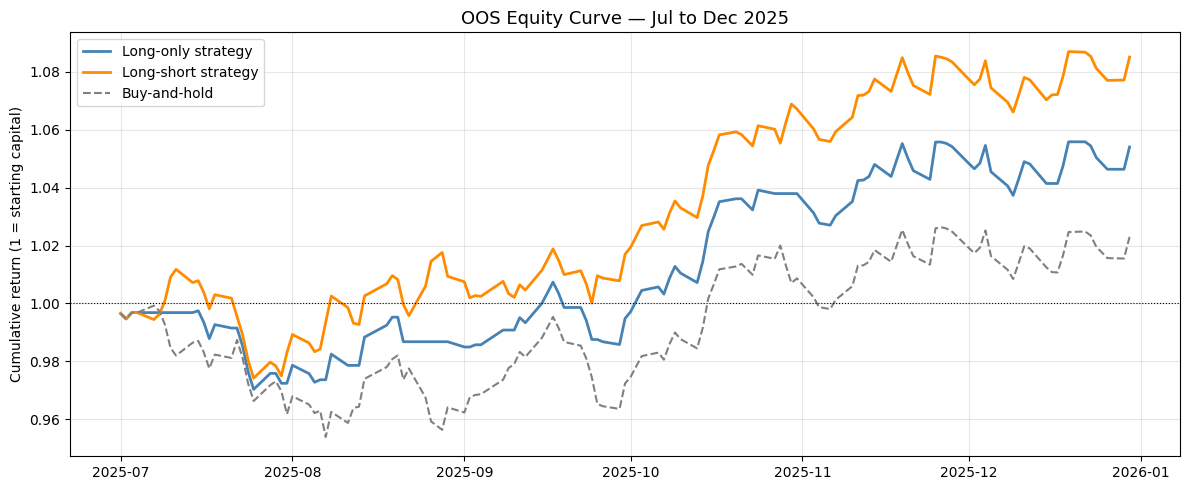

In [ ]:
cum_long = (1 + oos_bt['strat_ret_long']).cumprod()
cum_ls = (1 + oos_bt['strat_ret_ls']).cumprod()
cum_bnh = (1 + oos_bt['bnh_ret']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(oos_bt['date'], cum_long, label='Long-only strategy', color='steelblue', lw=2)
ax.plot(oos_bt['date'], cum_ls, label='Long-short strategy', color='darkorange', lw=2)
ax.plot(oos_bt['date'], cum_bnh, label='Buy-and-hold', color='gray', lw=1.5, linestyle='--')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':')
ax.set_ylabel('Cumulative return (1 = starting capital)')
ax.set_title('OOS Equity Curve — Jul to Dec 2025', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot4_equity_curve.png', dpi=150)
plt.show()

STATISTICS

In [ ]:
ls_returns = oos_bt['strat_ret_ls'].dropna().values
t_stat, p_val = stats.ttest_1samp(ls_returns, 0)

print(f'Long-short daily returns:')
print(f'Mean    : {ls_returns.mean():.5f}')
print(f'Std     : {ls_returns.std():.5f}')
print(f'T-stat  : {t_stat:.3f}')
print(f'P-value : {p_val:.3f}')
print()

if p_val < 0.05:
    print('p < 0.05: edge is statistically significant at 5% level.')
else:
    print('p >= 0.05: we CANNOT reject the null of zero edge.')

print()
print('Required sample for 80% power to detect Sharpe=0.5:')
sr_daily = 0.5 / np.sqrt(252)
required = int(2 * (1.645 + 0.842)**2 / sr_daily**2)
print(f'  ~{required} trading days (~{required//252} years)')

Long-short daily returns:
Mean    : 0.00067
Std     : 0.00495
T-stat  : 1.498
P-value : 0.137

p >= 0.05: we CANNOT reject the null of zero edge.

Required sample for 80% power to detect Sharpe=0.5:
  ~12469 trading days (~49 years)


Permutation AUC distribution (n=200):
  Mean     : 0.502
  95th pct : 0.591
  Our OOS AUC: 0.519

RESULT: Our model does NOT beat 95% of random-label models.


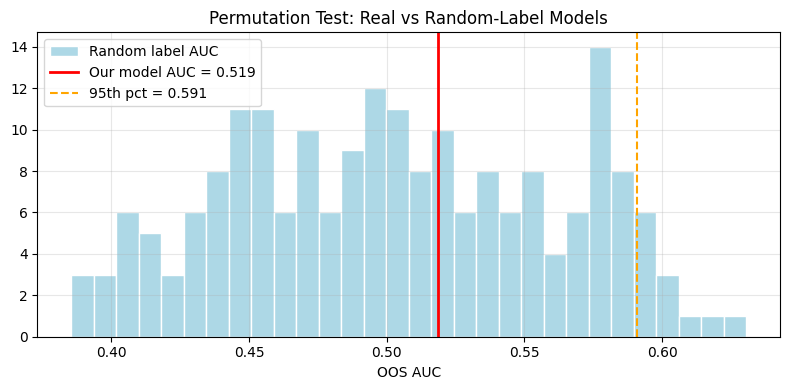

In [40]:
import lightgbm as lgb
np.random.seed(42)

N_PERMUTATIONS = 200
perm_aucs = []
X_tr = df_train[features].values
y_tr = df_train['target'].values

for i in range(N_PERMUTATIONS):
    y_shuffled = np.random.permutation(y_tr)
    m = lgb.LGBMClassifier(**LGB_PARAMS)
    m.fit(X_tr, y_shuffled)
    p = m.predict_proba(X_oos)[:, 1]
    if len(np.unique(y_oos)) >= 2:
        perm_aucs.append(roc_auc_score(y_oos, p))

perm_95 = np.percentile(perm_aucs, 95)
perm_mean = np.mean(perm_aucs)

print(f'Permutation AUC distribution (n={N_PERMUTATIONS}):')
print(f'  Mean     : {perm_mean:.3f}')
print(f'  95th pct : {perm_95:.3f}')
print(f'  Our OOS AUC: {oos_auc:.3f}')
print()

if oos_auc > perm_95:
    print('RESULT: Our model beats 95% of random-label models.')
else:
    print('RESULT: Our model does NOT beat 95% of random-label models.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_aucs, bins=30, color='lightblue', edgecolor='white', label='Random label AUC')
ax.axvline(oos_auc, color='red', lw=2, label=f'Our model AUC = {oos_auc:.3f}')
ax.axvline(perm_95, color='orange', lw=1.5, linestyle='--', label=f'95th pct = {perm_95:.3f}')
ax.set_xlabel('OOS AUC')
ax.set_title('Permutation Test: Real vs Random-Label Models', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_permutation_test.png', dpi=150)
plt.show()

In [42]:
boundaries = [
    ('2025-04-30', '2025-05-01'),
    ('2025-05-30', '2025-06-02'),
    ('2025-06-30', '2025-07-01'),
    ('2025-07-31', '2025-08-01'),
    ('2025-08-29', '2025-09-01'),
]

print('BOUNDARY SENSITIVITY')
print(f'{"IS end":12s} {"OOS start":12s} {"OOS rows":>9s} {"AUC":>8s} {"BalAcc":>9s}')
print('-' * 60)

for is_end, oos_start in boundaries:
    tr = master[(master['date'] <= is_end)].dropna(subset=features).copy()
    tr = tr[tr['next_ret'].abs() >= 0.001]
    te = master[(master['date'] >= oos_start)].dropna(subset=features).copy()

    if len(tr) < 100 or len(te) < 20:
        continue

    m = lgb.LGBMClassifier(**LGB_PARAMS)
    m.fit(tr[features].values, tr['target'].values)
    p = m.predict_proba(te[features].values)[:, 1]
    pr = (p >= 0.5).astype(int)
    y = te['target'].values

    if len(np.unique(y)) < 2:
        continue

    auc = roc_auc_score(y, p)
    bal = balanced_accuracy_score(y, pr)
    marker = ' <-- actual' if is_end == '2025-06-30' else ''
    print(f'{is_end:12s} {oos_start:12s} {len(te):>9d} {auc:>8.3f} {bal:>9.3f}{marker}')

BOUNDARY SENSITIVITY
IS end       OOS start     OOS rows      AUC    BalAcc
------------------------------------------------------------
2025-04-30   2025-05-01         168    0.511     0.507
2025-05-30   2025-06-02         147    0.483     0.468
2025-06-30   2025-07-01         126    0.519     0.488 <-- actual
2025-07-31   2025-08-01         103    0.556     0.533
2025-08-29   2025-09-01          84    0.556     0.481


I think, Possibly the backtest might be lying cuz:

1. TRANSACTION COSTS: We assume zero cost. Rounds-trips consume edge.
2. SLIPPAGE: Execution at exact close is unrealistic.
3. SURVIVORSHIP: Feature selection was done on full dataset.
4. REGIME CHANGE: Patterns learned in bull markets may fail in crashes.
5. SMALL OOS SAMPLE: 126 days is too short for high confidence.

In [43]:
for fname in ['plot4_equity_curve.png', 'plot5_permutation_test.png']:
    try:
        files.download(fname)
    except:
        print(f"Could not download {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ANALYSIS DONE